# Feature Exploration — Temperature Forecasting

Before training the LSTM, it's worth understanding what signal is actually
sitting in the dataset `real_data/fetch_data.py` produced. This notebook
walks through exploring `real_data/berlin_data.csv` (or whichever station
you fetched): looking at correlations, variance, and other summary
statistics for each feature relative to the **target** you're trying to
forecast, `temperature_2m`.

Each section below has a short explanation and a task. The code cells are
left empty on purpose — write your own code there to complete the task
before moving to the next section.

## 1. Load the data

`fetch_data.py` saved the aligned truth + NWP-forecast dataset to
`real_data/<station>_data.csv`, indexed by timestamp.

**Task:** Load the CSV with pandas. Make sure the date column becomes a
proper `DatetimeIndex` (not just a string column) — you'll need that for
the time-based work later in this notebook.

In [7]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import os
import numpy as np
import matplotlib.pyplot as plt

#ucitavanje i sredjivanje podataka

df=pd.read_csv("/home/polaznik/Desktop/nevena/TemperatureForecasting/real_data/petnica_data.csv")
#print(df.head())

df = df.iloc[600:]

df = df.reset_index(drop=True)
total_missing_rows = df.isna().any(axis=1).sum()
print("hello nema ovoliko", total_missing_rows)

print(df.head())


df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtype)

hello nema ovoliko 0
                        date  temperature_2m  surface_pressure  \
0  2024-01-26 00:00:00+00:00          5.4385        1000.61300   
1  2024-01-26 01:00:00+00:00          5.8385        1000.64923   
2  2024-01-26 02:00:00+00:00          5.6385        1001.02120   
3  2024-01-26 03:00:00+00:00          5.3885        1000.99830   
4  2024-01-26 04:00:00+00:00          4.8385        1001.04560   

   temperature_2m_previous_day1  temperature_2m_previous_day3  \
0                        5.1335                        4.4335   
1                        4.7835                        4.4335   
2                        4.3335                        4.1335   
3                        4.1335                        3.7835   
4                        4.1335                        3.4835   

   temperature_2m_previous_day5  temperature_2m_previous_day7  \
0                         5.162                         6.882   
1                         4.862                         6.982

## 2. Get familiar with the data

Before any modeling, always check the basics — shape, column types,
missing values, and the date range actually covered. These often reveal
fetch bugs or gaps you'd otherwise miss.

**Task:**
- Print the shape of the DataFrame and its column dtypes.
- Count missing values per column.
- Print the first and last timestamp to confirm the covered date range.

In [ ]:
df.info()
df.columns
df.shape
df.dtypes
df.head()
df.tail()
#

<class 'pandas.DataFrame'>
RangeIndex: 22272 entries, 0 to 22271
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   date                            22272 non-null  datetime64[us, UTC]
 1   temperature_2m                  22272 non-null  float64            
 2   surface_pressure                22272 non-null  float64            
 3   temperature_2m_previous_day1    22272 non-null  float64            
 4   temperature_2m_previous_day3    22272 non-null  float64            
 5   temperature_2m_previous_day5    22272 non-null  float64            
 6   temperature_2m_previous_day7    22272 non-null  float64            
 7   surface_pressure_previous_day1  22272 non-null  float64            
 8   surface_pressure_previous_day3  22272 non-null  float64            
 9   surface_pressure_previous_day5  22272 non-null  float64            
 10  surface_pressure_prev

,date,temperature_2m,surface_pressure,temperature_2m_previous_day1,temperature_2m_previous_day3,temperature_2m_previous_day5,temperature_2m_previous_day7,surface_pressure_previous_day1,surface_pressure_previous_day3,surface_pressure_previous_day5,surface_pressure_previous_day7
22267,2026-08-10 19:00:00+00:00,26.638500,991.17975,27.0665,25.588501,26.388500,27.388500,991.01770,991.87866,992.03900,992.80080
22268,2026-08-10 20:00:00+00:00,26.088501,991.62500,24.8165,24.238499,25.038502,26.538502,991.13450,991.77220,992.22620,992.83220
22269,2026-08-10 21:00:00+00:00,25.638500,991.88270,23.1165,22.388500,24.038502,25.688500,991.19480,991.62460,992.34210,992.96094
22270,2026-08-10 22:00:00+00:00,25.288502,992.14820,22.3165,21.088501,23.638500,24.988499,991.52106,991.71497,992.31024,993.10090
22271,2026-08-10 23:00:00+00:00,24.888500,992.11664,21.8665,20.338501,23.538502,24.438500,991.68005,991.55646,992.20490,993.25287


## 3. Visualize the target over time

Plotting the raw series is the fastest way to spot obvious patterns —
daily cycles, seasonal trend, missing chunks, or outliers — before diving
into summary numbers.

**Task:**
- Plot `temperature_2m` against the date index for the full dataset.
- Then plot just a single week of it, so the daily cycle is clearly
  visible.

/tmp/ipykernel_314722/2533512390.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


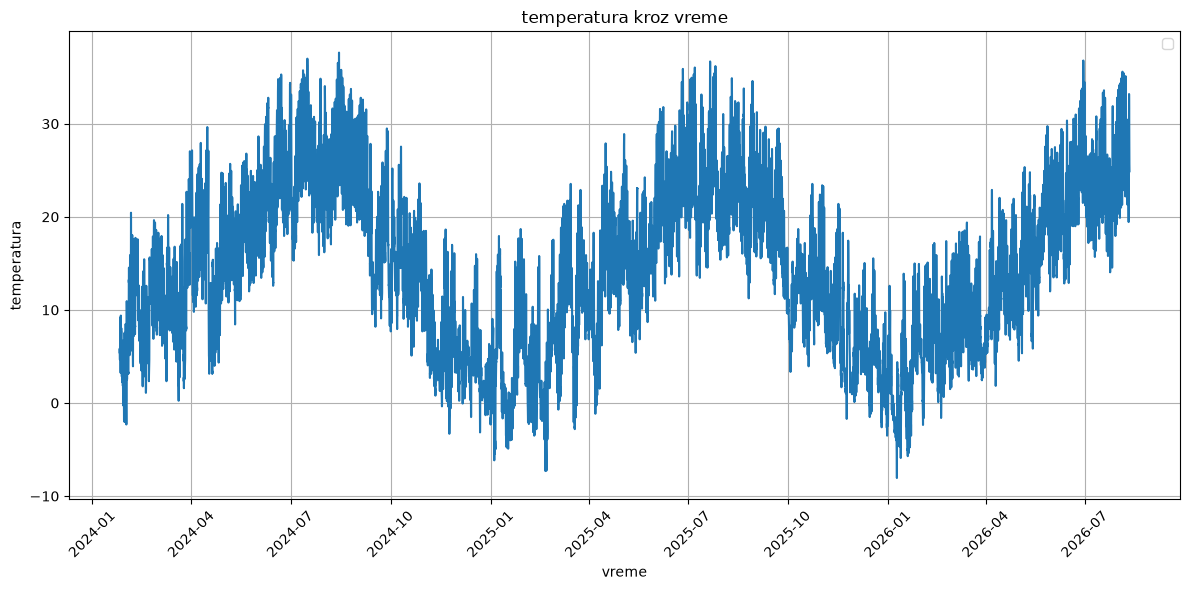

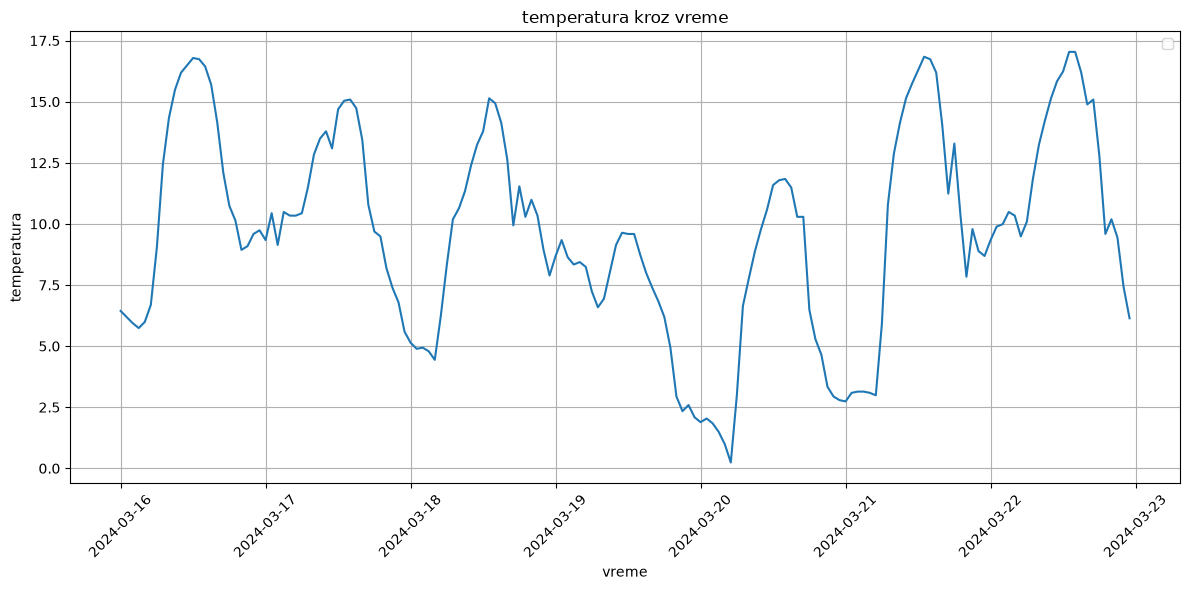

In [19]:


def plot(x, y):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)


    plt.xlabel("vreme")
    plt.ylabel("temperatura")
    plt.title("temperatura kroz vreme")
    plt.legend()
    plt.grid(True)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

temp = df['temperature_2m']
date= df['date']
plot(date, temp)


nedelja = df[
    (df["date"] >= "2024-03-16 00:00:00+00:00") &
    (df["date"] < "2024-03-23 00:00:00+00:00")
]

tempnedelja = temp[
    (df["date"] >= "2024-03-16 00:00:00+00:00") &
    (df["date"] < "2024-03-23 00:00:00+00:00")
]

plot(nedelja["date"],tempnedelja)

## 4. Distribution of each feature

A histogram shows you the spread, skew, and any suspicious outliers in a
feature — things a single mean/std number can hide.

**Task:**
- Plot a histogram for every numeric column (`DataFrame.hist()` does this
  for all columns at once).
- Note anything that looks off: an unexpected spike, a suspiciously flat
  distribution, or values that seem out of physical range.

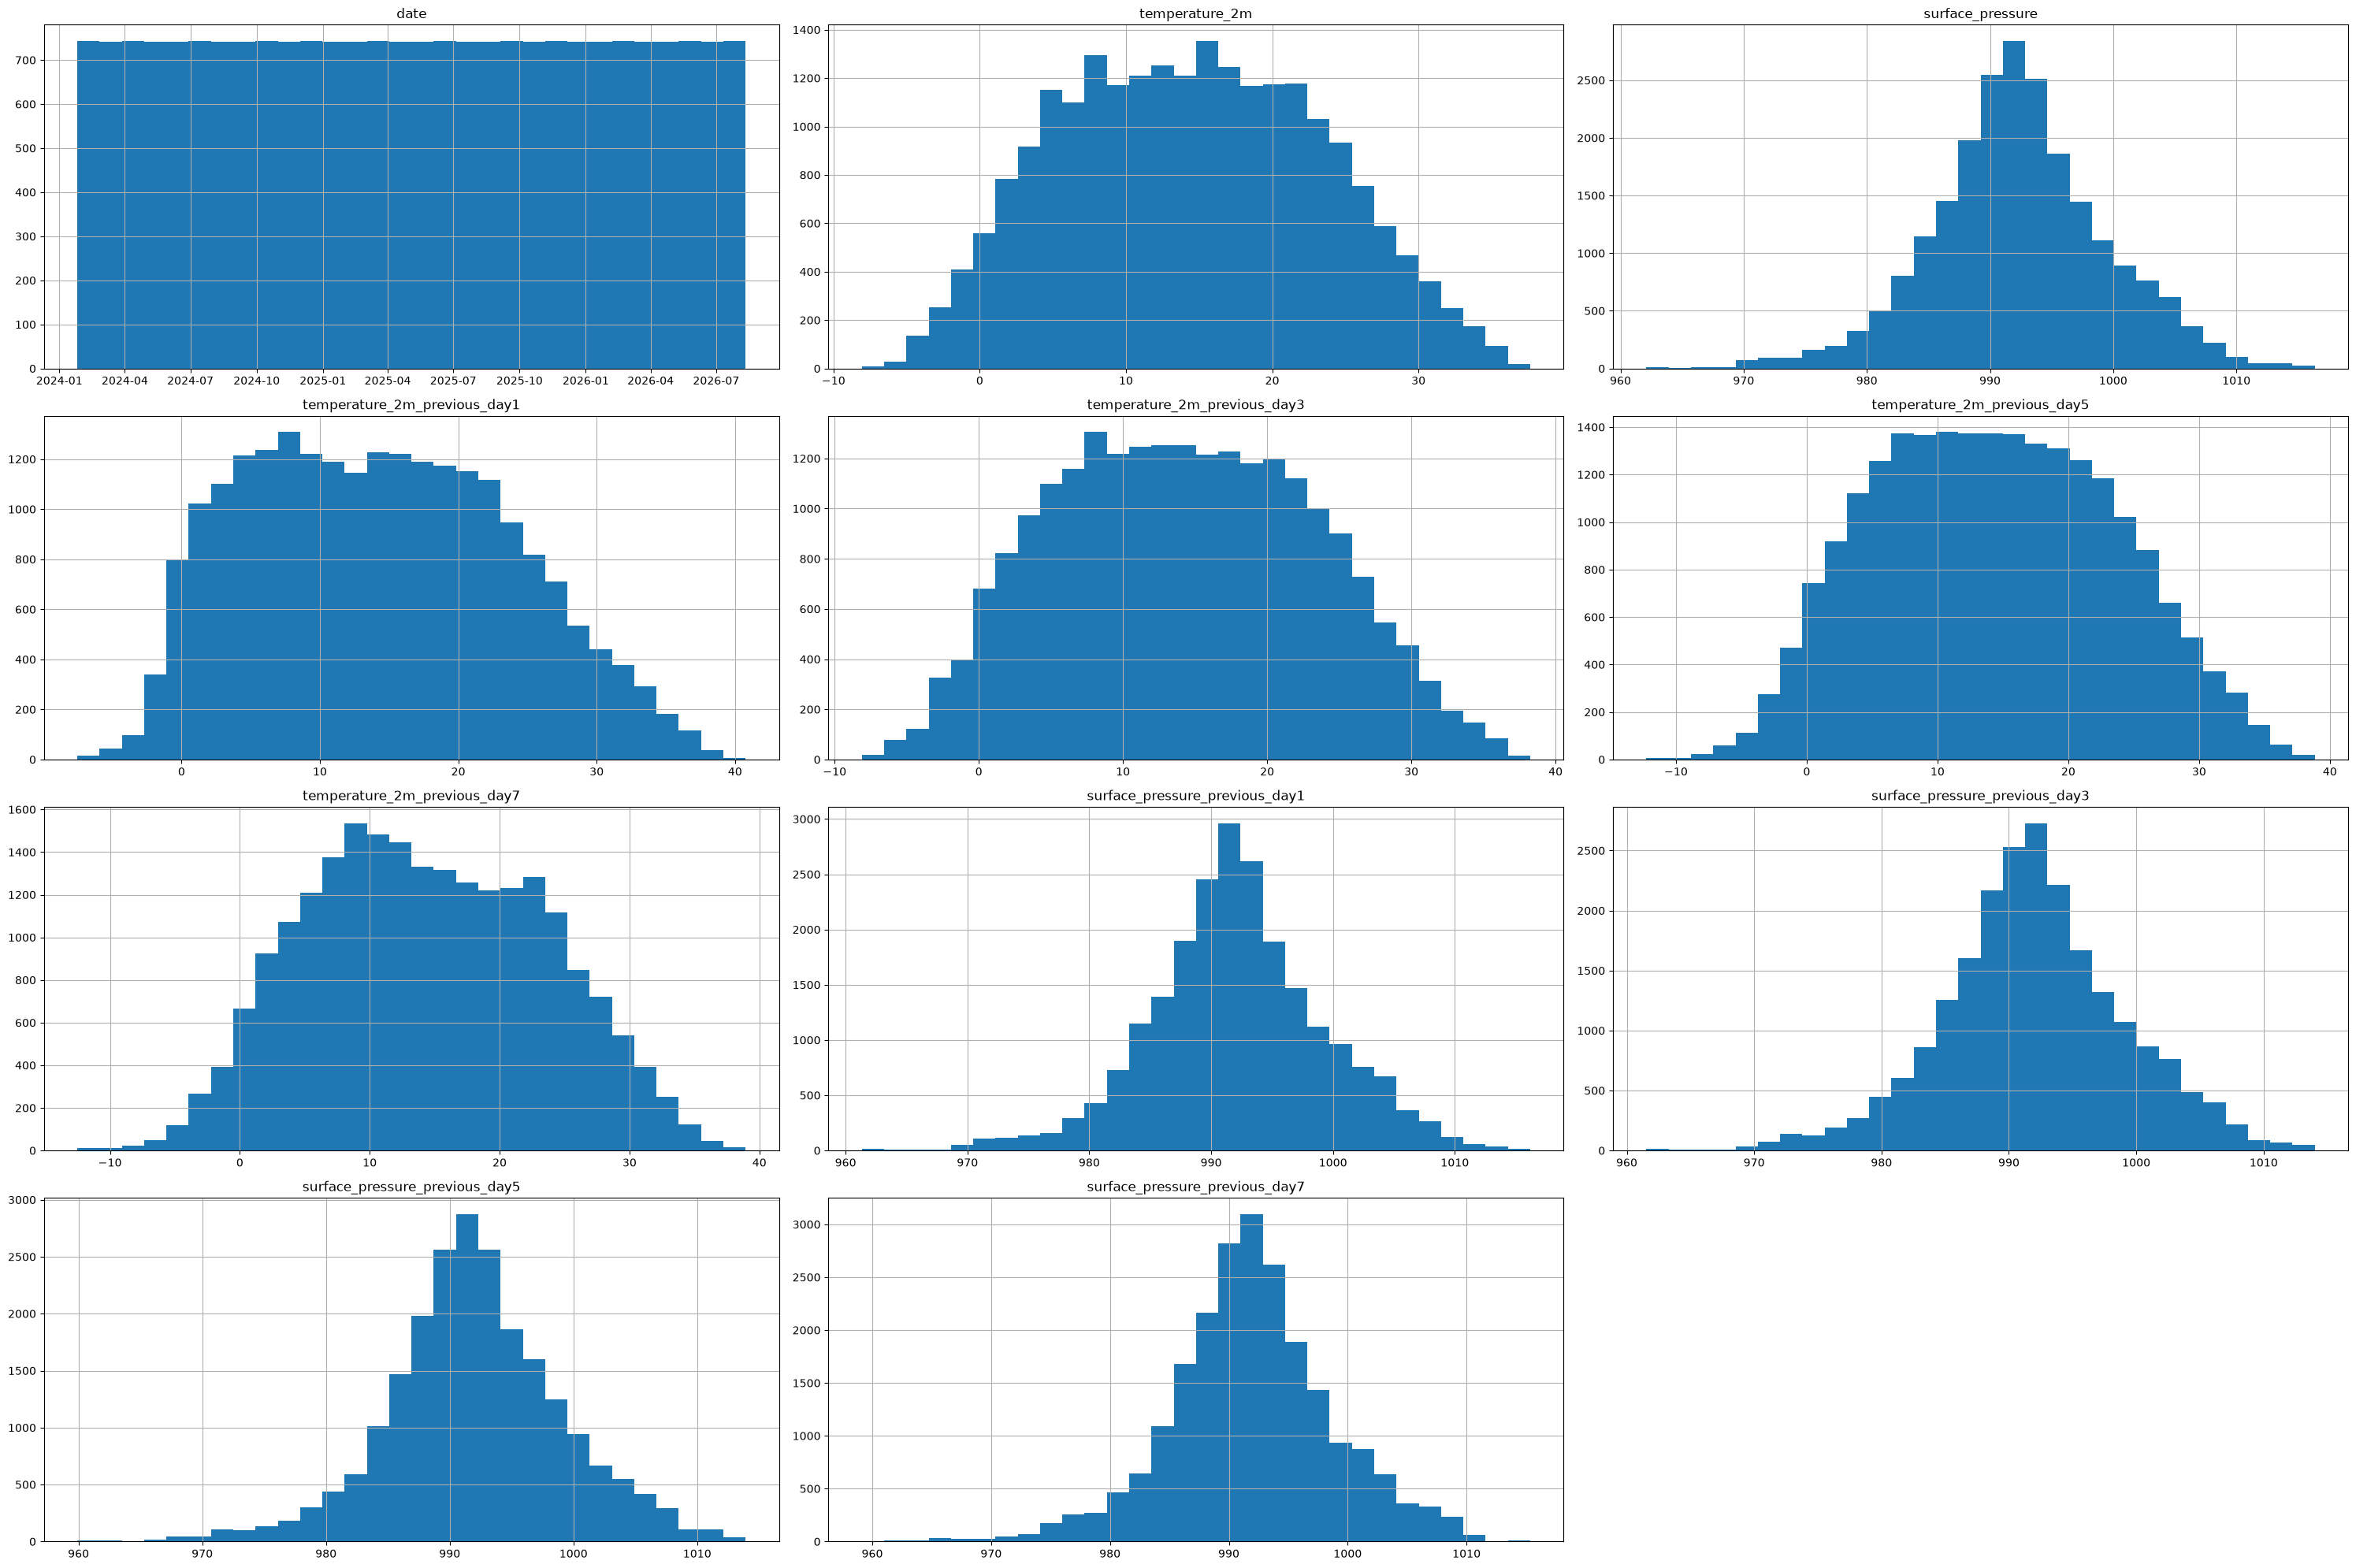

In [24]:
df.hist(figsize=(30, 20), bins=30)

plt.tight_layout()
plt.show()

## 5. Correlation coefficients with the target

The Pearson correlation coefficient measures the strength of the
*linear* relationship between two variables, from -1 (perfect negative)
to +1 (perfect positive), with 0 meaning no linear relationship. Keep in
mind: two variables can have a strong *non-linear* relationship and still
show a weak Pearson correlation, so this isn't the whole picture — just a
useful first pass.

**Task:**
- Compute the Pearson correlation of every feature with `temperature_2m`
  (`DataFrame.corr()`), and sort the results by absolute value.
- Which feature correlates most strongly with the target? Does that match
  your intuition?
- Plot the full correlation matrix as a heatmap so you can see how
  features relate to *each other*, not just to the target.

korelacije sa merenom temperaturom  temperature_2m                    1.000000
temperature_2m_previous_day3      0.985730
temperature_2m_previous_day1      0.983848
temperature_2m_previous_day5      0.970827
temperature_2m_previous_day7      0.939500
surface_pressure_previous_day7   -0.225943
surface_pressure_previous_day5   -0.237319
surface_pressure_previous_day3   -0.238435
surface_pressure                 -0.246318
surface_pressure_previous_day1   -0.253976
Name: temperature_2m, dtype: float64


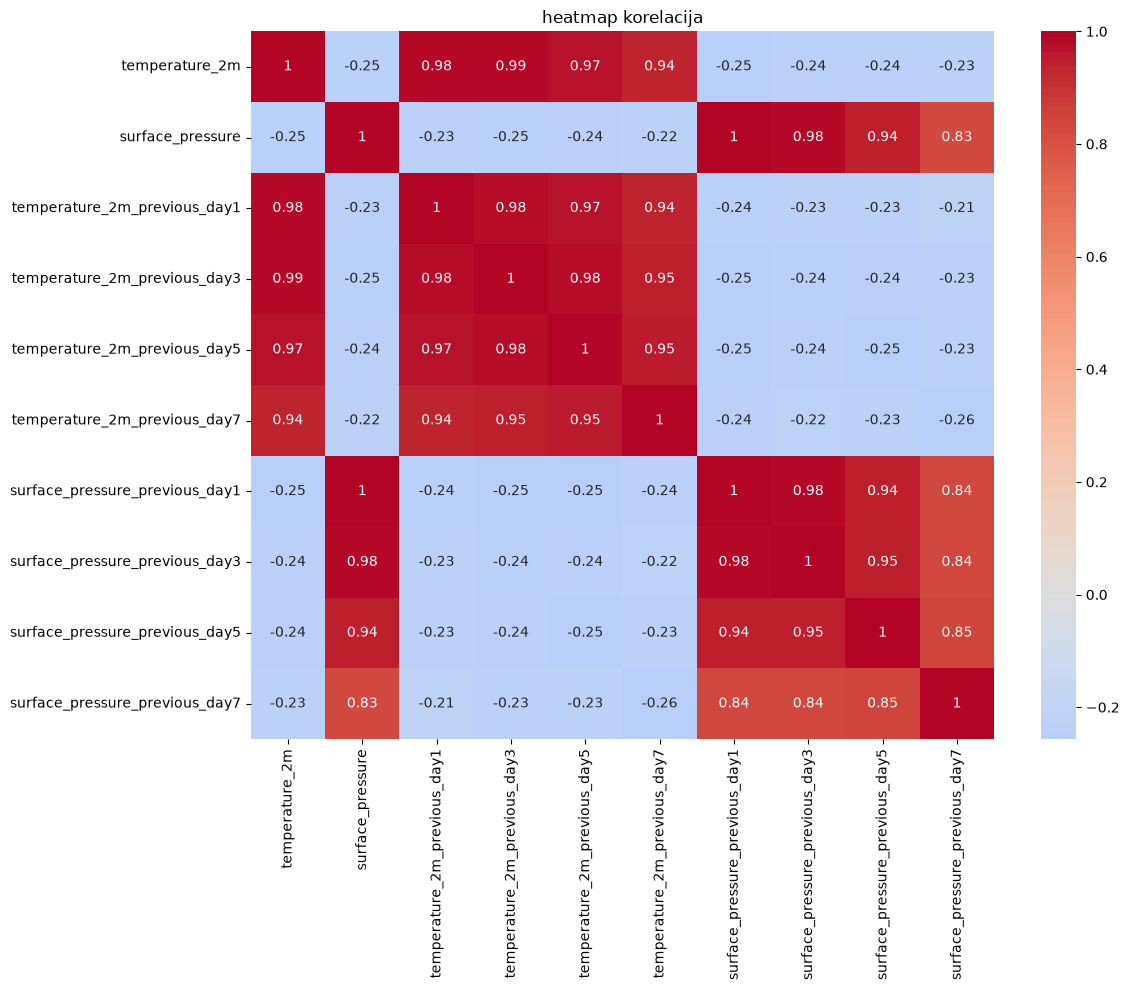

In [45]:
korelacije = df.corr(numeric_only=True)["temperature_2m"]

korelacije = korelacije.sort_values(
    ascending=False
)

print("korelacije sa merenom temperaturom ", korelacije)

import seaborn as sns

korelacijesve=df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    korelacijesve,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("heatmap korelacija")
plt.tight_layout()
plt.show()


temp1d = korelacije["temperature_2m_previous_day1"]


## 6. Variance and spread of each feature

Variance measures how spread out a feature's values are around its mean.
A feature with (near) zero variance carries almost no information — it
barely changes, so it can't help a model distinguish one moment from
another, no matter how "correlated" it superficially looks.

Because these features live on very different scales (temperature in °C
vs. pressure in hPa), raw variance isn't directly comparable across
columns. The **coefficient of variation** (`std / mean`) is a scale-free
way to compare spread across variables with different units.

**Task:**
- Compute the variance and standard deviation of each numeric column.
- Compute the coefficient of variation for each column and compare it
  across variables.
- Are there any near-constant columns that might not be useful for the
  model?

In [41]:
brojevi = df.select_dtypes(include="number")

#variance - kvadratna srednja vrednost odstupanja

variance= brojevi.var()
print("--------ovo su variance", variance)

#standardna devijacija - srednja vrednost odstupanja
stdevijacija=brojevi.std()
print("--------ovo je standardna devijaicja", stdevijacija)

#koeficient 
coefvariation=stdevijacija/brojevi.mean()
print("------------------",coefvariation)

--------ovo su variance temperature_2m                    79.407852
surface_pressure                  51.177833
temperature_2m_previous_day1      89.621021
temperature_2m_previous_day3      81.808580
temperature_2m_previous_day5      82.981992
temperature_2m_previous_day7      82.490572
surface_pressure_previous_day1    51.498957
surface_pressure_previous_day3    51.343556
surface_pressure_previous_day5    50.588338
surface_pressure_previous_day7    47.497782
dtype: float64
--------ovo je standardna devijaicja temperature_2m                    8.911108
surface_pressure                  7.153868
temperature_2m_previous_day1      9.466838
temperature_2m_previous_day3      9.044810
temperature_2m_previous_day5      9.109445
temperature_2m_previous_day7      9.082432
surface_pressure_previous_day1    7.176277
surface_pressure_previous_day3    7.165442
surface_pressure_previous_day5    7.112548
surface_pressure_previous_day7    6.891863
dtype: float64
------------------ temperature_2m      

In [ ]:
#da mozemo da poredimo
coefvariation=stdevijacija/brojevi.mean()
print(coefvariation)
uprocentima=coefvariation*100
print("u procentima", uprocentima)

#surface pressure je near-constant

temperature_2m                    0.617389
surface_pressure                  0.007209
temperature_2m_previous_day1      0.661117
temperature_2m_previous_day3      0.634862
temperature_2m_previous_day5      0.636157
temperature_2m_previous_day7      0.633141
surface_pressure_previous_day1    0.007233
surface_pressure_previous_day3    0.007224
surface_pressure_previous_day5    0.007169
surface_pressure_previous_day7    0.006948
dtype: float64
u procentima temperature_2m                    61.738864
surface_pressure                   0.720945
temperature_2m_previous_day1      66.111739
temperature_2m_previous_day3      63.486177
temperature_2m_previous_day5      63.615675
temperature_2m_previous_day7      63.314117
surface_pressure_previous_day1     0.723304
surface_pressure_previous_day3     0.722382
surface_pressure_previous_day5     0.716946
surface_pressure_previous_day7     0.694796
dtype: float64


## 7. Autocorrelation of the target

Since this is a time series, how strongly a value relates to its *own*
past values (autocorrelation) matters a lot — it directly informs how
large a lookback window the LSTM needs to see useful history. The
autocorrelation at lag *k* is the correlation between the series and a
copy of itself shifted by *k* steps (`Series.autocorr(lag=k)`).

**Task:**
- Compute the autocorrelation of `temperature_2m` at lags of 1, 6, 12,
  24, 48, and 168 hours (1 hour up to 1 week).
- Plot autocorrelation vs. lag. At what lag does it drop off? What does
  that suggest about how many past hours the LSTM's input window should
  cover?

*(Optional stretch: `statsmodels.graphics.tsaplots.plot_acf` gives a
nicer ACF plot with confidence intervals built in.)*

[np.float64(0.991228136637347), np.float64(0.9719693498452877), np.float64(0.9460713257926217), np.float64(0.9161048771412463), np.float64(0.884302217389476), np.float64(0.8525693525415101), np.float64(0.8224321697506639), np.float64(0.7954431171894013), np.float64(0.7728949176074753), np.float64(0.7556694019160403), np.float64(0.7443408965843554), np.float64(0.7392021130686942), np.float64(0.7404923542909171), np.float64(0.7477803454459798), np.float64(0.7606117466056808), np.float64(0.7784208186297309), np.float64(0.8003507433262), np.float64(0.8250050406989017), np.float64(0.8508496287368525), np.float64(0.876361942282911), np.float64(0.8996859518203925), np.float64(0.9187353198382635), np.float64(0.9312383144685732), np.float64(0.934669492141641), np.float64(0.9271143496723888), np.float64(0.9105165287730895), np.float64(0.8874562955475678), np.float64(0.860329789695808), np.float64(0.8310780996132718), np.float64(0.8016424930713373), np.float64(0.7736771481782596), np.float64(0.74

/tmp/ipykernel_314722/2461346463.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


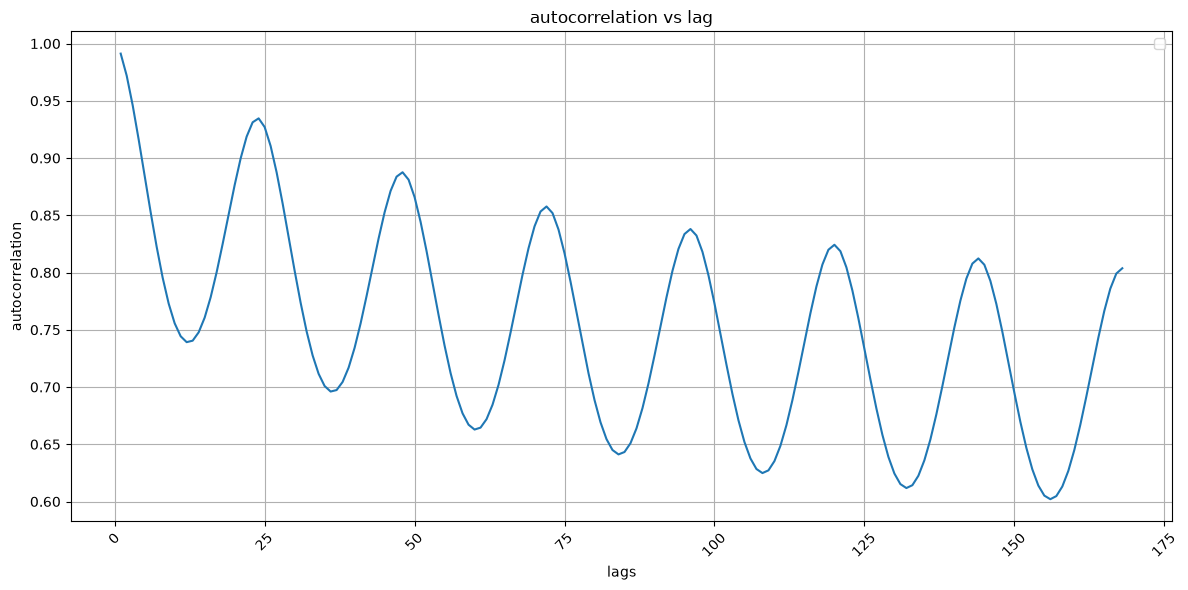

In [57]:
temp=df["temperature_2m"]
lags=[1,6,12,24,48,168]

lags = [i+1 for i in range(168)]

autocorrelation=[]

for lag in lags:
    vrednost=temp.autocorr(lag=lag)
    autocorrelation.append(vrednost)

print(autocorrelation)

def plot1(x, y, x1, y1, naziv):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)


    plt.xlabel(x1)
    plt.ylabel(y1)
    plt.title(naziv)
    plt.legend()
    plt.grid(True)


    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot1(lags,autocorrelation, "lags", "autocorrelation", "autocorrelation vs lag")

#smanjuje se do otp 12h i onda opet raste do oko 24h, a zatim se sve vise smanjuje
#mislim da bi trebalo koristiti podatke do 48 sati unazad, ali nebi bio preveliki problem uzeti i podatke od nedeju dana jer je koeficient oko 80 sto je takodje veliko 

## 8. How good is the NWP baseline already?

The `temperature_2m_previous_day{N}` columns aren't just another
feature — they're the archived operational NWP forecast made N days
before each timestamp. Comparing them against the true `temperature_2m`
tells you how strong a "physics baseline" the LSTM will eventually be
measured against.

**Task:**
- For each `temperature_2m_previous_day{N}` column, compute its
  correlation with `temperature_2m`, and its RMSE against
  `temperature_2m`.
- How do correlation and RMSE change as the lead time N grows? Does that
  match your expectations about forecast skill decaying with lead time?

In [ ]:

temp1d = korelacije["temperature_2m_previous_day1"]
temp3d = korelacije["temperature_2m_previous_day3"]
temp5d = korelacije["temperature_2m_previous_day5"]
temp7d = korelacije["temperature_2m_previous_day7"]

print(temp1d,temp3d,temp5d,temp7d)


def srednjakvadratna(predikcija):
   
    y_true = df["temperature_2m"]
    y_pred = df[predikcija]
    mse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mse


srkgreska1d= srednjakvadratna("temperature_2m_previous_day1")
srkgreska3d= srednjakvadratna("temperature_2m_previous_day3")
srkgreska5d= srednjakvadratna("temperature_2m_previous_day5")
srkgreska7d= srednjakvadratna("temperature_2m_previous_day7")

print(srkgreska1d,srkgreska3d,srkgreska5d,srkgreska7d)

#sto je ranija predikcija, to je manja korelacija, a rmse veca

0.9838481683823678 0.9857301626640305 0.9708272631305981 0.9395000184450937
1.7455242585953796 1.5339126356356623 2.1882273913336276 3.1352545702024166


## 9. Summary

Write a short summary of what you found. There's no single right
answer here — the point is to reason from what you actually saw above.

**Your answers:**

- Which features look most useful for forecasting temperature?

  Imamo samo jos jedan feature, sto je surface temperature, a korelacija njega i temperature je prilicno mala tako da mislim da nije preterano koristan za to.

- Are there any features you'd drop, or engineer differently (e.g.
  combine, transform)?

  Mislim da ne, takodje, verovatno bi bila dobra ideja preuzeti jos neki feature osim surface pressure.

- Based on the autocorrelation, how far back should the LSTM's input
  window look?

Mislim da bi trebalo koristiti podatke do 48 sati unazad, ali nebi bio preveliki problem uzeti i podatke od nedeju dana jer je koeficient oko 80 sto je takodje veliko.

- How big a gap does the LSTM need to close relative to the NWP
  baseline?

  *(your answer here)*

Standardization


0   -1.009420
1   -0.964532
2   -0.986976
3   -1.015031
4   -1.076751
Name: temperature_2m, dtype: float64


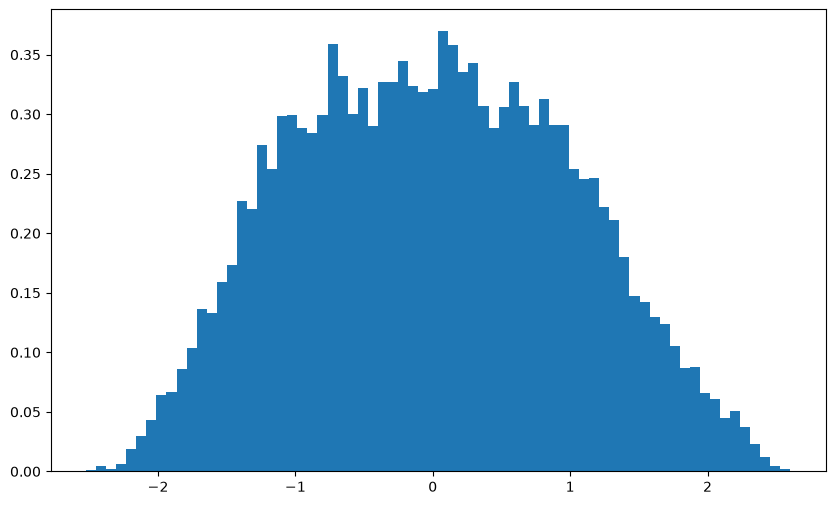

0    1.163379
1    1.168443
2    1.220439
3    1.217238
4    1.223849
Name: surface_pressure, dtype: float64


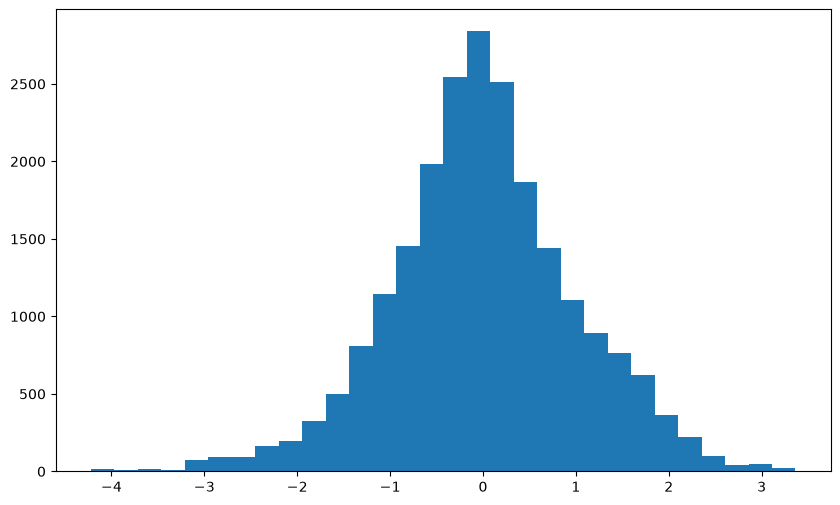

In [125]:
import scipy.stats as stats

temp = df['temperature_2m']
sf = df['surface_pressure']


temp1 = df['temperature_2m_previous_day1']
temp3= df['temperature_2m_previous_day3']
temp5 = df['temperature_2m_previous_day5']
temp7 = df['temperature_2m_previous_day7']


sf1 = df['surface_pressure_previous_day1']
sf3= df['surface_pressure_previous_day3']
sf5 = df['surface_pressure_previous_day5']
sf7= df['surface_pressure_previous_day7']


#temp.hist(figsize=(30, 20), bins=30)

#srednja vrednost i standardna devijacija
mu = temp.mean()
sigma = temp.std()

musf= sf.mean()
sigmasf= sf.std()

def standardizacija1(x):
    mu=x.mean()
    sigma=x.std()
    x=(x-mu)/sigma
    print(x.head())
    return x


def standardizacija(x, mu, sigma):
    x=(x-mu)/sigma
    print(x.head())
    return x


standtemp=standardizacija(temp,mu,sigma)
#print(standtemp.head())
#standtemp.hist(figsize=(30, 20), bins=30)

#standtemp.hist(figsize=(30, 20), bins=30)

plt.figure(figsize=(10, 6))
plt.hist(standtemp, bins=70, density=True)
plt.show()


standsf=standardizacija(sf,musf,sigmasf)
#standsf.hist(figsize=(30, 20), bins=30)

plt.figure(figsize=(10, 6))
plt.hist(standsf, bins=30)
plt.show()




0   -0.970329
1   -1.007301
2   -1.054835
3   -1.075961
4   -1.075961
Name: temperature_2m_previous_day1, dtype: float64


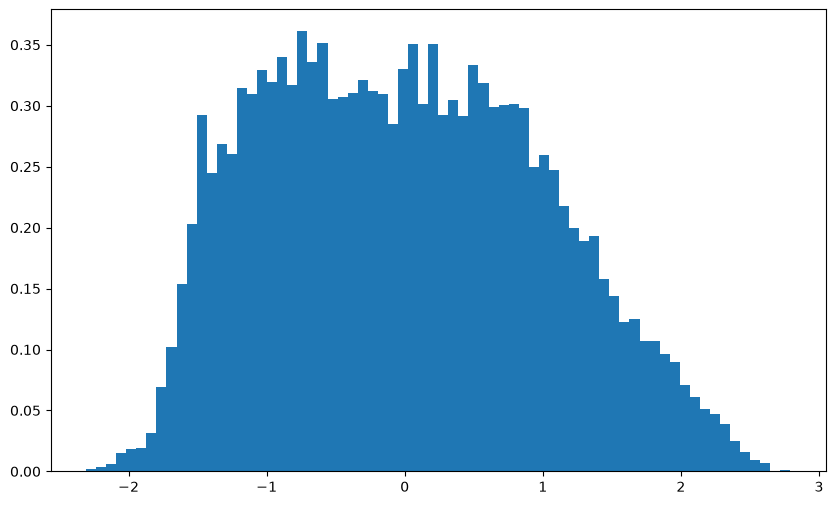

0   -1.084975
1   -1.084975
2   -1.118144
3   -1.156840
4   -1.190008
Name: temperature_2m_previous_day3, dtype: float64


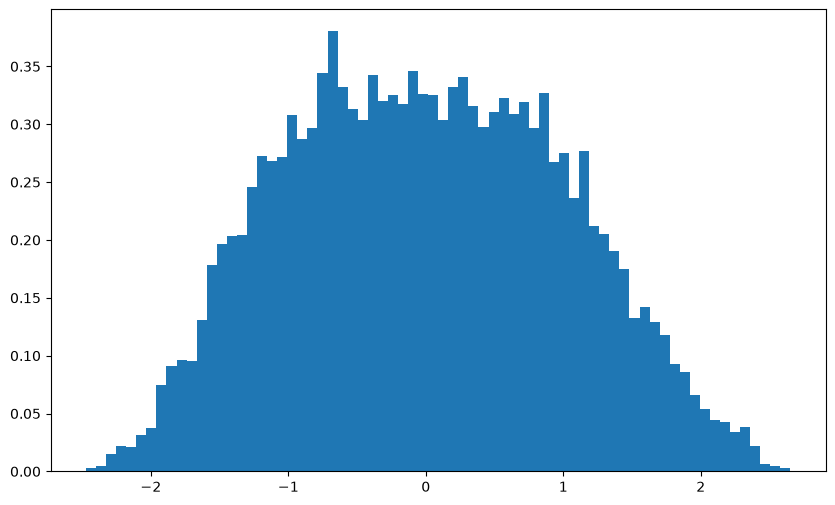

0   -1.005275
1   -1.038208
2   -1.076630
3   -1.109562
4   -1.158962
Name: temperature_2m_previous_day5, dtype: float64


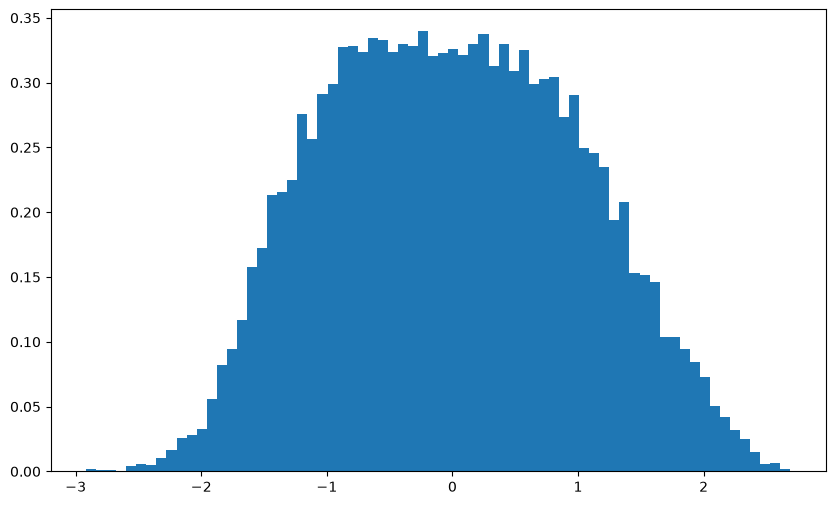

0   -0.821700
1   -0.810690
2   -0.816195
3   -0.810690
4   -0.805185
Name: temperature_2m_previous_day7, dtype: float64


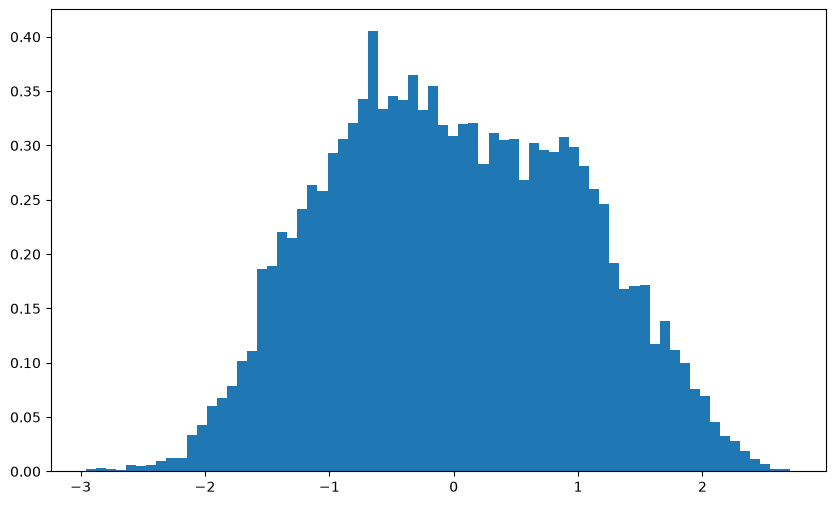

0    1.270127
1    1.333622
2    1.327865
3    1.298108
4    1.311688
Name: surface_pressure_previous_day1, dtype: float64


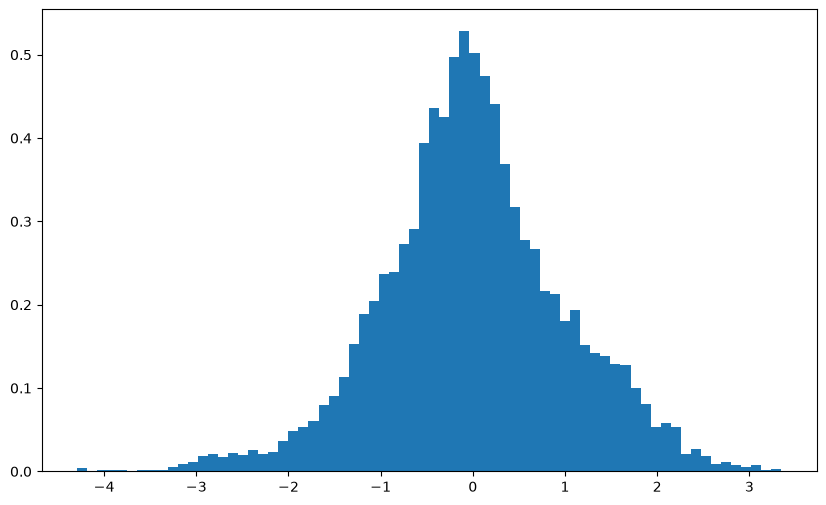

0    1.241290
1    1.309318
2    1.319059
3    1.328186
4    1.351492
Name: surface_pressure_previous_day3, dtype: float64


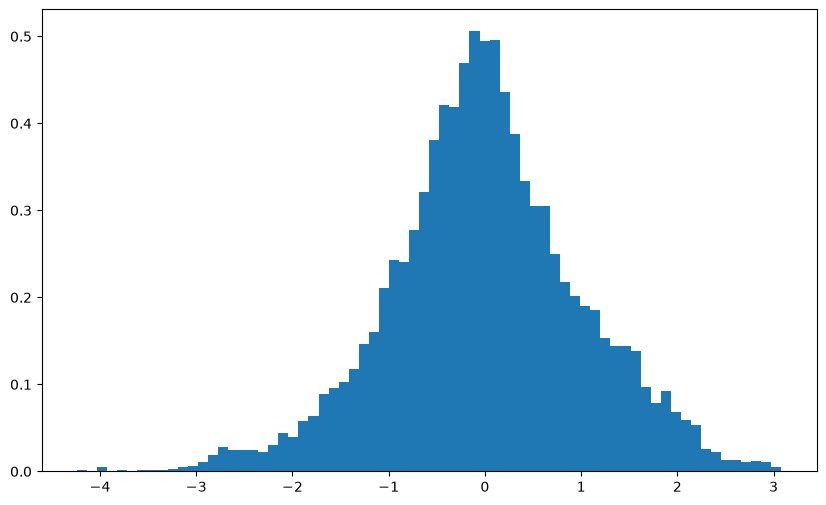

0    1.541447
1    1.564989
2    1.587878
3    1.625072
4    1.687772
Name: surface_pressure_previous_day5, dtype: float64


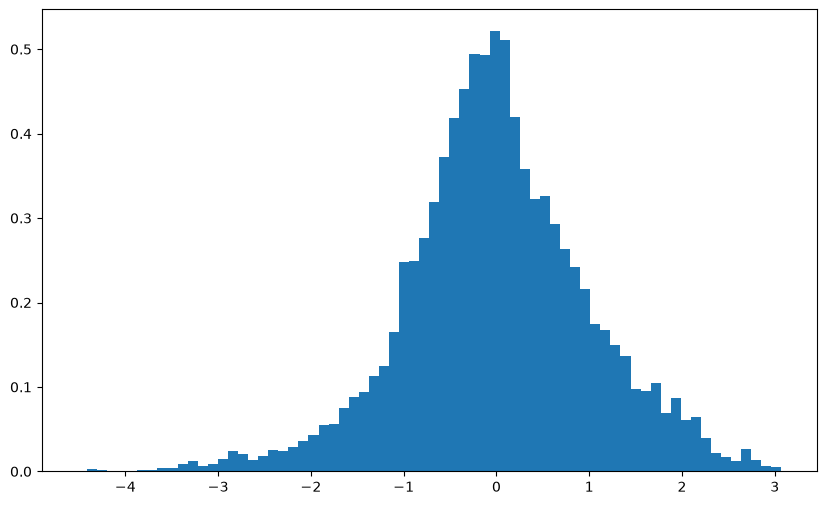

0    1.774500
1    1.747532
2    1.704455
3    1.662658
4    1.620863
Name: surface_pressure_previous_day7, dtype: float64


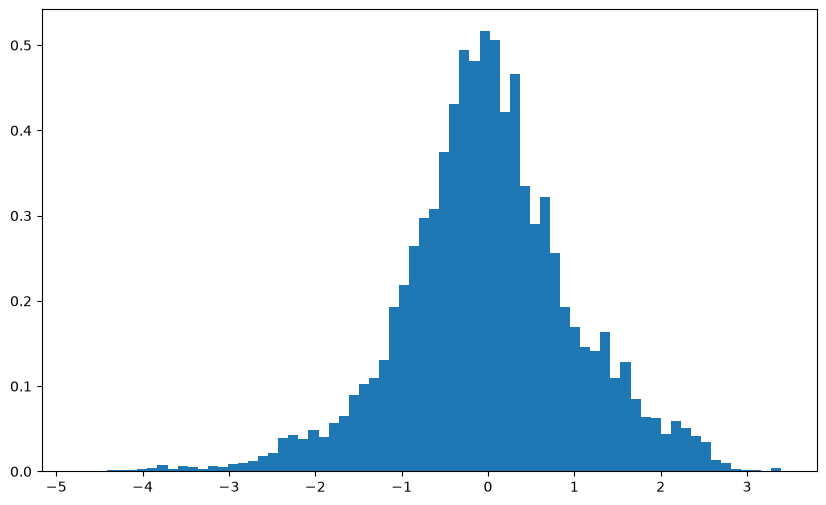

In [105]:
sttemp1=standardizacija1(temp1)
plt.figure(figsize=(10, 6))
plt.hist(sttemp1, bins=70, density=True)
plt.show()
sttemp3=standardizacija1(temp3)
plt.figure(figsize=(10, 6))
plt.hist(sttemp3, bins=70, density=True)
plt.show()
sttemp5=standardizacija1(temp5)
plt.figure(figsize=(10, 6))
plt.hist(sttemp5, bins=70, density=True)
plt.show()
sttemp7=standardizacija1(temp7)
plt.figure(figsize=(10, 6))
plt.hist(sttemp7, bins=70, density=True)
plt.show()


stsf1=standardizacija1(sf1)
plt.figure(figsize=(10, 6))
plt.hist(stsf1, bins=70, density=True)
plt.show()
stsf3=standardizacija1(sf3)
plt.figure(figsize=(10, 6))
plt.hist(stsf3, bins=70, density=True)
plt.show()
stsf5=standardizacija1(sf5)
plt.figure(figsize=(10, 6))
plt.hist(stsf5, bins=70, density=True)
plt.show()
stsf7=standardizacija1(sf7)
plt.figure(figsize=(10, 6))
plt.hist(stsf7, bins=70, density=True)
plt.show()
lista=[temp1,temp3,temp5,temp7]




Ukupno: 22272
Train: 17817
Validation: 2227
Test: 2228


/tmp/ipykernel_314722/3538631359.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


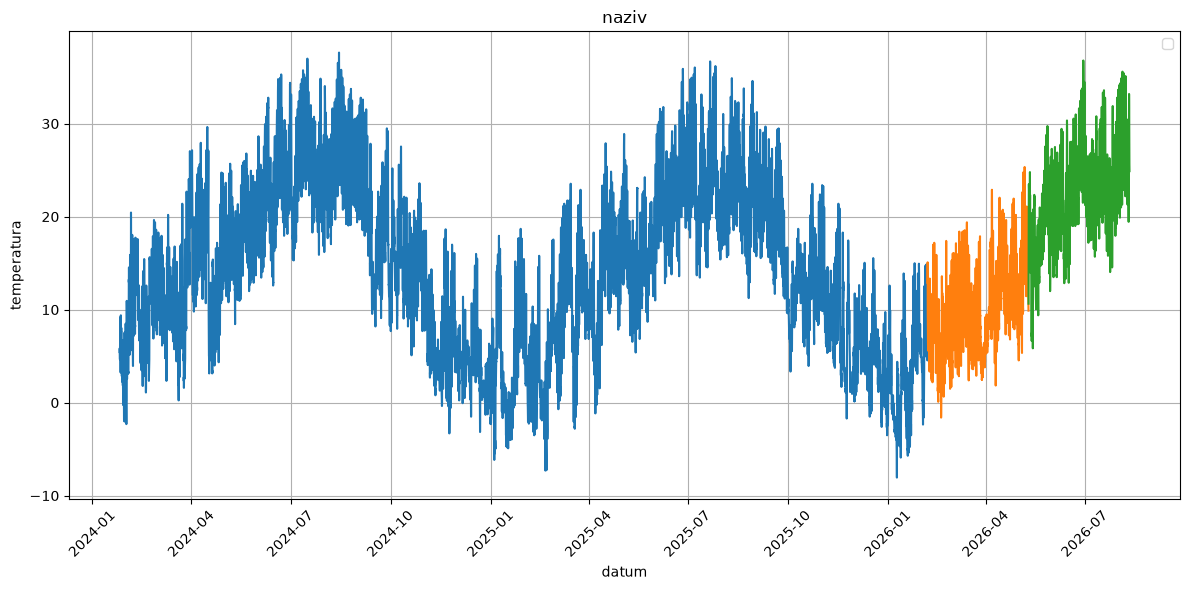

In [150]:
from sklearn.model_selection import train_test_split
date=df["date"]
n=len(df)

trsize=int(n*0.8)
valsize=int(len(df)*0.1)

trening=df.iloc[:trsize]
validation=df.iloc[trsize:trsize+valsize]
test=df.iloc[trsize+valsize:]


print("Ukupno:", len(date))

print("Train:", len(trening))
print("Validation:", len(validation))
print("Test:", len(test))

test.head()

def plot2(x, y, x1, y1, naziv,x11,y22,x3,y3):
    plt.figure(figsize=(12, 6))

    plt.plot(x, y)
    plt.plot(x11, y22)
    plt.plot(x3, y3)


    plt.xlabel(x1)
    plt.ylabel(y1)
    plt.title(naziv)
    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

plot2(trening["date"],trening["temperature_2m"],"datum","temperatura","naziv",validation["date"],validation["temperature_2m"],test["date"],test["temperature_2m"])
#plot(validation["date"],validation["temperature_2m"])
#plot(test["date"],test["temperature_2m"])